Coefficient: 41933.84939381274
Intercept: 44459.729169078666
Predicted Values:
[114958.91676996 150606.88213964 190393.71844449 285059.38345102
 200663.31816103 242165.24890609 257647.22610228 199229.18051176
 245893.1681172  384677.43607096]
Mean Squared Error: 7091157771.76555
R2 Score: 0.45885918903846656


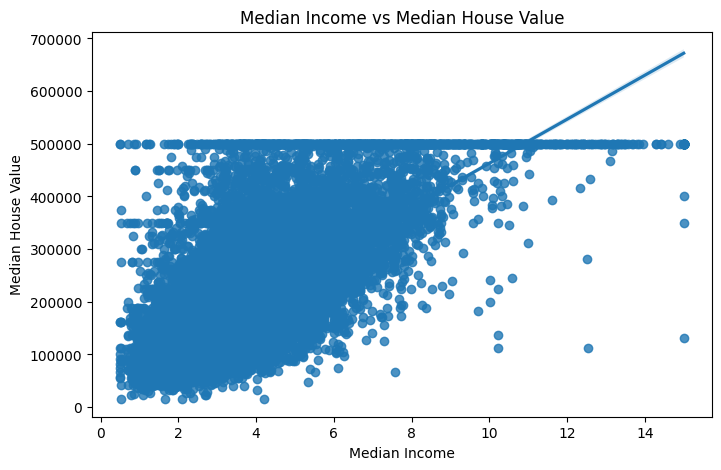

In [11]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# Load Dataset
df = pd.read_csv("housing.csv")
# Select Independent and Dependent Variables
X = df[["median_income"]]
y = df["median_house_value"]
# Split Dataset into Training and Testing Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# Create Linear Regression Model
model = LinearRegression()
# Train the Model
model.fit(X_train, y_train)
# Display Coefficient and Intercept
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)
# Predict House Values
y_pred = model.predict(X_test)
# Display First 10 Predictions
print("Predicted Values:")
print(y_pred[:10])
# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
# Calculate R2 Score
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)
# Scatter Plot with Regression Line
plt.figure(figsize=(8, 5))
sns.regplot(
    x="median_income",
    y="median_house_value",
    data=df
)
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("Median Income vs Median House Value")
plt.show()

In [12]:
import pandas as pd
# Load housing dataset
df = pd.read_csv("housing.csv")
correlation = df["total_rooms"].corr(
    df["median_house_value"]
)
print("Correlation between total_rooms and median_house_value:")
print(correlation)

Correlation between total_rooms and median_house_value:
0.1341531138065631


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# Load Dataset
df = pd.read_csv("housing.csv")
# Q.2 Multiple Linear Regression
# Independent variables
X = df[
    [
        "median_income",
        "housing_median_age",
        "total_rooms",
        "population",
        "households"
    ]
]
# Dependent variable
y = df["median_house_value"]
# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
# Create Model
multiple_model = LinearRegression()
# Train Model
multiple_model.fit(X_train, y_train)
# Predict
y_pred_multiple = multiple_model.predict(X_test)
# Evaluate Model
multiple_r2 = r2_score(y_test, y_pred_multiple)
multiple_mse = mean_squared_error(y_test, y_pred_multiple)
# Display Results
print("Multiple Linear Regression")
print("--------------------------------")
print("R2 Score:", multiple_r2)
print("Mean Squared Error:", multiple_mse)
print("\nCoefficients:")
for feature, coefficient in zip(X.columns, multiple_model.coef_):
    print(feature, ":", coefficient)
print("\nIntercept:", multiple_model.intercept_)

Multiple Linear Regression
--------------------------------
R2 Score: 0.5490012551168503
Mean Squared Error: 5909928044.702565

Coefficients:
median_income : 46219.776281000864
housing_median_age : 1855.6978290928719
total_rooms : -14.35136899793929
population : -39.46279086454465
households : 217.26171044838694

Intercept: -39681.04301111502


In [14]:
import pandas as pd
import numpy as np
# Load the housing dataset
df = pd.read_csv("housing.csv")
# Q.1 Complete Correlation Matrix
correlation_matrix = df.corr(numeric_only=True)
print("Complete Correlation Matrix:")
print(correlation_matrix)
# Get only unique correlation pairs
mask = np.triu(
    np.ones(correlation_matrix.shape),
    k=1
).astype(bool)
corr_pairs = correlation_matrix.where(mask).stack()
# Strongest Positive Correlation
strongest_positive = corr_pairs.idxmax()
positive_value = corr_pairs.max()
# Strongest Negative Correlation
strongest_negative = corr_pairs.idxmin()
negative_value = corr_pairs.min()
# Weakest Correlation
weakest = corr_pairs.abs().idxmin()
weakest_value = corr_pairs.loc[weakest]
print("\nStrongest Positive Correlation:")
print(strongest_positive, "=", positive_value)
print("\nStrongest Negative Correlation:")
print(strongest_negative, "=", negative_value)
print("\nWeakest Correlation:")
print(weakest, "=", weakest_value)

Complete Correlation Matrix:
                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069608 -0.066983           -0.320451     0.930380   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069608    0.099773    0.055310      -0.015176   
latitude                 -0.066983   -0.108785   -0.0710

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                  41          880           129.0   
1    -122.22     37.86                  21         7099          1106.0   
2    -122.24     37.85                  52         1467           190.0   
3    -122.25     37.85                  52         1274           235.0   
4    -122.25     37.85                  52         1627           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0         322         126         8.3252              452600        NEAR BAY  
1        2401        1138         8.3014              358500        NEAR BAY  
2         496         177         7.2574              352100        NEAR BAY  
3         558         219         5.6431              341300        NEAR BAY  
4         565         259         3.8462              342200        NEAR BAY  
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
      

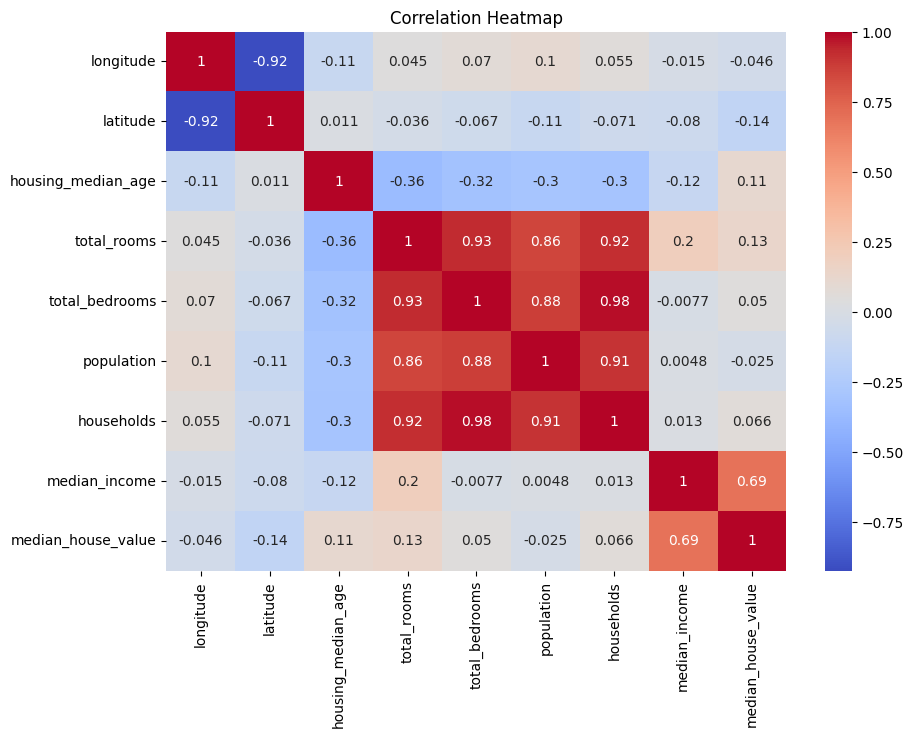

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load Dataset
df = pd.read_csv("housing.csv")
# Display First Five Records
print(df.head())
# Display Numerical Columns
print(df.select_dtypes(include="number").columns)
# Calculate Correlation Matrix
correlation = df.corr(numeric_only=True)
print(correlation)
# Display Correlation Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()